In [ ]:
import time
import statistics

def heapify(arr, n, i):
    largest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left

    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)


def heap_sort(arr):
    n = len(arr)

    # Build max heap
    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)

    # Extract maximum repeatedly
    for i in range(n - 1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        heapify(arr, i, 0)


sizes = list(range(100, 10001, 500))
times = []
runs = 5

for n in sizes:
    # Fixed deterministic input
    arr = [(i * 37) % 100000 for i in range(n)]

    measurements = []

    for _ in range(runs):
        test_arr = arr.copy()

        start = time.perf_counter_ns()
        heap_sort(test_arr)
        end = time.perf_counter_ns()

        measurements.append(end - start)

    times.append(statistics.median(measurements))

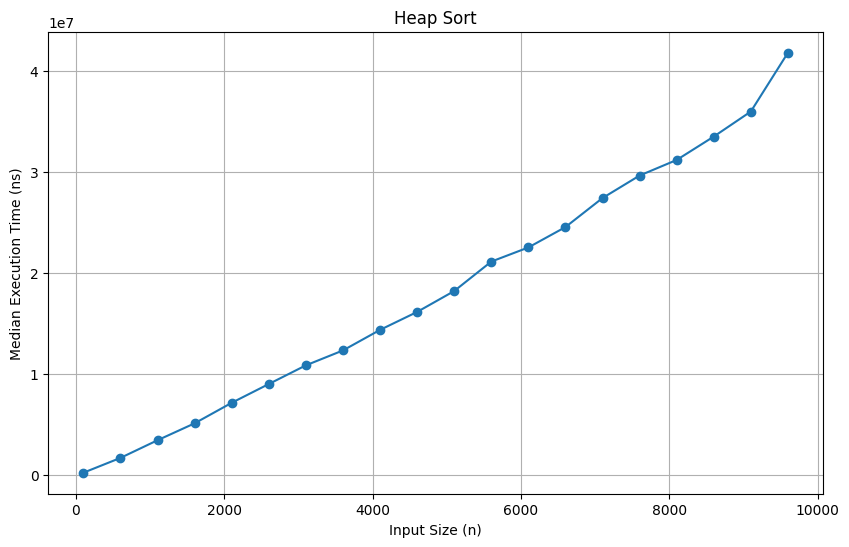

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.title("Heap Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Median Execution Time (ns)")
plt.grid(True)
plt.show()